In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [4]:
df.drop(columns=['UDI', 'Product ID','TWF', 'HDF', 'PWF', 'OSF','RNF'],inplace=True)

In [5]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='str')

In [6]:
type_map={
    "L":0,
    "M":1,
    "H":2
}
df["Type"]=df["Type"].map(type_map)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


In [7]:
x=df.drop(columns=['Machine failure'])
y=df["Machine failure"]

In [8]:
x.columns = (x.columns.str.replace(r"[\[\]<>]", "", regex=True))
x.columns.to_list()

['Type',
 'Air temperature K',
 'Process temperature K',
 'Rotational speed rpm',
 'Torque Nm',
 'Tool wear min']

In [9]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
y.value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
from sklearn.metrics import recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,accuracy_score,precision_score

In [12]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

lr_model=LogisticRegression(random_state=42)
lr_model.fit(x_train,y_train)
y_pred_lr=lr_model.predict(x_test)

def modeleval(classifier,xtest,ytest,ypred):
    print(f"Model Name:{classifier}")
    print('-'*40)

    accuracy=accuracy_score(ytest,ypred)
    recall=recall_score(ytest,ypred)
    precision=precision_score(ytest,ypred)
    f1=f1_score(ytest,ypred)
    roc_auc=roc_auc_score(ytest,classifier.predict_proba(xtest)[:,1])

    print(f"Accuracy:{accuracy}")
    print(f"Recall Score:{recall}")
    print(f"Precision Score:{precision}")
    print(f"F1 Score:{f1}")
    print(f"ROC_AUC Score:{roc_auc}")

    return accuracy, recall, precision, f1, roc_auc


accuracy_lr,recall_lr,precision_lr,f1_lr,roc_auc_lr=modeleval(lr_model,x_test,y_test,y_pred_lr)


Model Name:LogisticRegression(random_state=42)
----------------------------------------
Accuracy:0.974
Recall Score:0.29508196721311475
Precision Score:0.6666666666666666
F1 Score:0.4090909090909091
ROC_AUC Score:0.8963721370657514


In [13]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)
y_pred_dt=dt_model.predict(x_test)

accuracy_dt,recall_dt,precision_dt,f1_dt,roc_auc_dt=modeleval(dt_model,x_test,y_test,y_pred_dt)

Model Name:DecisionTreeClassifier(random_state=42)
----------------------------------------
Accuracy:0.9775
Recall Score:0.7377049180327869
Precision Score:0.6081081081081081
F1 Score:0.6666666666666666
ROC_AUC Score:0.8613743775310918


In [14]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)

accuracy_rf,recall_rf,precision_rf,f1_rf,roc_auc_rf=modeleval(rf_model,x_test,y_test,y_pred_rf)

Model Name:RandomForestClassifier(random_state=42)
----------------------------------------
Accuracy:0.9845
Recall Score:0.5901639344262295
Precision Score:0.8571428571428571
F1 Score:0.6990291262135923
ROC_AUC Score:0.9636960068989424


In [15]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(random_state=42)
xgb_model.fit(x_train,y_train)
y_pred_xgb=xgb_model.predict(x_test)

accuracy_xgb,recall_xgb,precision_xgb,f1_xgb,roc_auc_xgb=modeleval(xgb_model,x_test,y_test,y_pred_xgb)

Model Name:XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
----------------------------------------
Accuracy:0.9825
Recall Score:0.6065573770491803
Precision Score:0.7708333333333334
F1 Score:0.6788990825688074
ROC_AUC Score:0.9718124096416101


In [16]:
from lightgbm import LGBMClassifier
lgb_model=LGBMClassifier(random_state=42)
lgb_model.fit(x_train,y_train)
y_pred_lgb=lgb_model.predict(x_test)

accuracy_lgb,recall_lgb,precision_lgb,f1_lgb,roc_auc_lgb=modeleval(lgb_model,x_test,y_test,y_pred_lgb)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 278, number of negative: 7722
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034750 -> initscore=-3.324208
[LightGBM] [Info] Start training from score -3.324208
Model Name:LGBMClassifier(random_state=42)
----------------------------------------
Accuracy:0.9875
Recall Score:0.7049180327868853
Precision Score:0.86
F1 Score:0.7747747747747747
ROC_AUC Score:0.9791340812823917


In [17]:
comparison_df=pd.DataFrame({
    "Model":["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier","XGBClassifier","LGBMClassifier"],
    "Accuracy":[accuracy_lr,accuracy_dt,accuracy_rf,accuracy_xgb,accuracy_lgb],
    "Precision":[precision_lr,precision_dt,precision_rf,precision_xgb,precision_lgb],
    "Recall Score":[recall_lr,recall_dt,recall_rf,recall_xgb,recall_lgb],
    "F1 Score":[f1_lr,f1_dt,f1_rf,f1_xgb,f1_lgb],
    "ROC-AUC Score":[roc_auc_lr,roc_auc_dt,roc_auc_rf,roc_auc_xgb,roc_auc_lgb]
    })

comparison_df =comparison_df.sort_values(
    by="ROC-AUC Score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall Score,F1 Score,ROC-AUC Score
0,LGBMClassifier,0.9875,0.860000,0.704918,0.774775,0.979134
1,XGBClassifier,0.9825,0.770833,0.606557,0.678899,0.971812
2,RandomForestClassifier,0.9845,0.857143,0.590164,0.699029,0.963696
3,LogisticRegression,0.9740,0.666667,0.295082,0.409091,0.896372
4,DecisionTreeClassifier,0.9775,0.608108,0.737705,0.666667,0.861374


In [18]:
from sklearn.model_selection import RandomizedSearchCV
param_dist_lgb={
    "n_estimators":[100,200,300,500],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[-1,5,10,15],
    "num_leaves": [15, 31, 50, 70],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}
rf_lgb=RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_distributions=param_dist_lgb,
    cv=5,
    n_iter=20,
    scoring="recall",
    n_jobs=-1,
    random_state=42
)

rf_lgb.fit(x_train, y_train)

print("Best Parameters:", rf_lgb.best_params_)
print("Best CV Recall:", rf_lgb.best_score_)

lgb_tuned_model = rf_lgb.best_estimator_

y_pred_lgb_tune = lgb_tuned_model.predict(x_test)

accuracy_lgb_tune, recall_lgb_tune, precision_lgb_tune, f1_lgb_tune, roc_auc_lgb_tune = modeleval(
    lgb_tuned_model,
    x_test,
    y_test,
    y_pred_lgb_tune
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 278, number of negative: 7722
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000295 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034750 -> initscore=-3.324208
[LightGBM] [Info] Start training from score -3.324208
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [19]:
param_dist_xgb={
    "n_estimators":[100,200,300,500],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[5,10,15],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

rf_XGB=RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=param_dist_xgb,
    cv=5,
    n_iter=20,
    scoring="recall",
    n_jobs=-1,
    random_state=42
)

rf_XGB.fit(x_train, y_train)

print("Best Parameters:", rf_XGB.best_params_)
print("Best CV Recall:", rf_XGB.best_score_)

xgb_tuned_model = rf_XGB.best_estimator_

y_pred_xgb_tune = xgb_tuned_model.predict(x_test)

accuracy_xgb_tune, recall_xgb_tune, precision_xgb_tune, f1_xgb_tune, roc_auc_xgb_tune = modeleval(
    xgb_tuned_model,
    x_test,
    y_test,
    y_pred_xgb_tune
)

Best Parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV Recall: 0.6551298701298702
Model Name:XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
----------------------------------------
Accuracy:0.9865
Recall Score:0.65573

In [20]:
comparison_df=pd.DataFrame({
    "Model":["LogisticRegression","DecisionTreeClassifier","RandomForestClassifier","XGBClassifier","LGBMClassifier","XGB Tuned","LGBM Tuned"],
    "Accuracy":[accuracy_lr,accuracy_dt,accuracy_rf,accuracy_xgb,accuracy_lgb,accuracy_xgb_tune,accuracy_lgb_tune],
    "Precision":[precision_lr,precision_dt,precision_rf,precision_xgb,precision_lgb,precision_xgb_tune,precision_lgb_tune],
    "Recall Score":[recall_lr,recall_dt,recall_rf,recall_xgb,recall_lgb,recall_xgb_tune,recall_lgb_tune],
    "F1 Score":[f1_lr,f1_dt,f1_rf,f1_xgb,f1_lgb,f1_xgb_tune,f1_lgb_tune],
    "ROC-AUC Score":[roc_auc_lr,roc_auc_dt,roc_auc_rf,roc_auc_xgb,roc_auc_lgb,roc_auc_xgb_tune,roc_auc_lgb_tune]
    })

comparison_df =comparison_df.sort_values(
    by="ROC-AUC Score",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall Score,F1 Score,ROC-AUC Score
0,LGBMClassifier,0.9875,0.860000,0.704918,0.774775,0.979134
1,LGBM Tuned,0.9875,0.860000,0.704918,0.774775,0.977798
2,XGB Tuned,0.9865,0.869565,0.655738,0.747664,0.974408
3,XGBClassifier,0.9825,0.770833,0.606557,0.678899,0.971812
4,RandomForestClassifier,0.9845,0.857143,0.590164,0.699029,0.963696
5,LogisticRegression,0.9740,0.666667,0.295082,0.409091,0.896372
6,DecisionTreeClassifier,0.9775,0.608108,0.737705,0.666667,0.861374


Feature Importance and SHAP

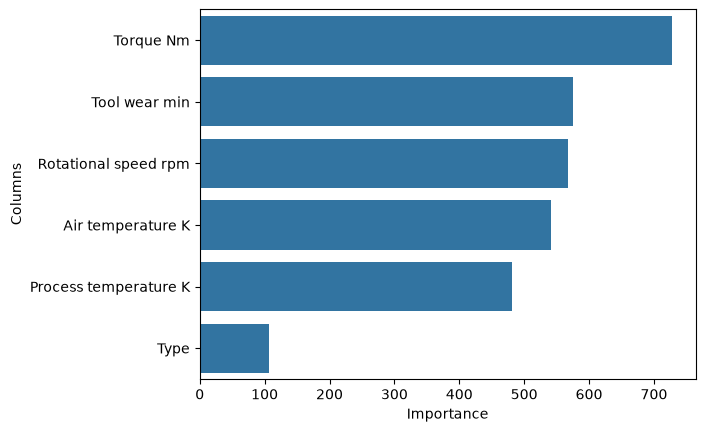

In [21]:
import seaborn as sns

top_features=pd.DataFrame({
    "Columns":x.columns,
    "Importance":lgb_model.feature_importances_
})

top_features=top_features.sort_values(by="Importance",ascending=False)
top_features

sns.barplot(data=top_features,x="Importance",y="Columns")
plt.show()


In [23]:
import shap
print(shap.__version__)

0.51.0


In [25]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(x_test)
print(type(shap_values))

<class 'numpy.ndarray'>


c:\Users\Shravan Kundap\anaconda3\envs\ai_portfolio\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


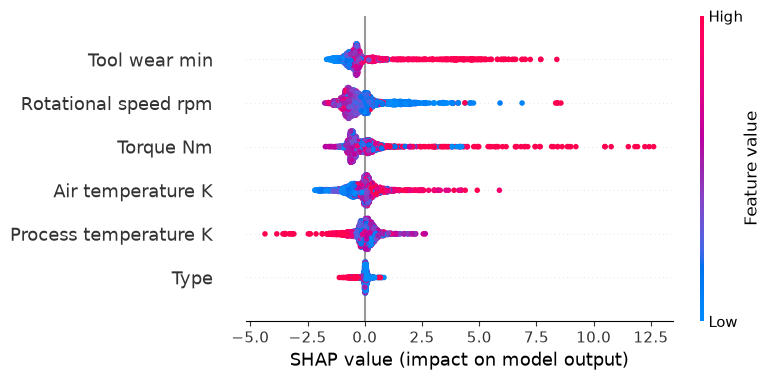

In [26]:
shap.summary_plot(
    shap_values,
    x_test,
    feature_names=x_test.columns
)

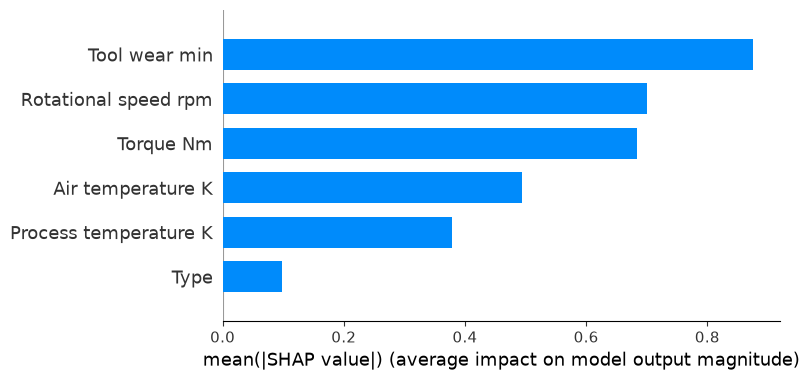

In [27]:
shap.summary_plot(
    shap_values,
    x_test,
    feature_names=x_test.columns,
    plot_type="bar"
)


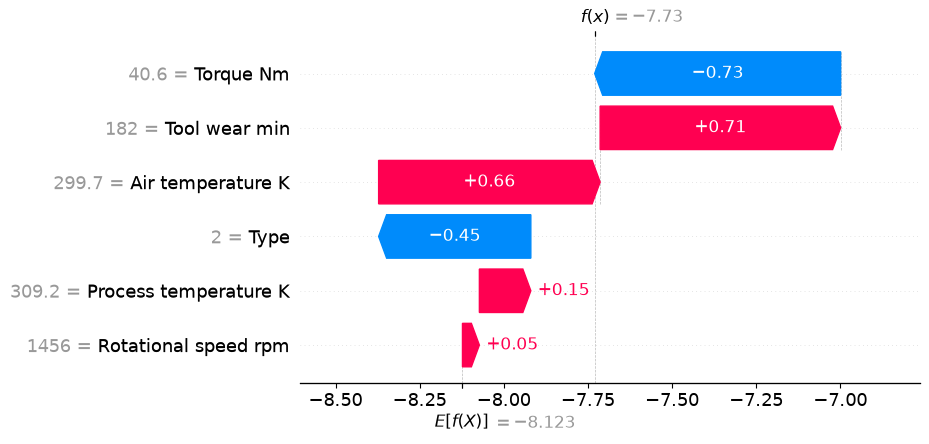

In [28]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[10],
        base_values=explainer.expected_value,
        data=x_test.iloc[10],
        feature_names=x_test.columns
    )
)

In [30]:
import pickle

artifacts = {
    "model": lgb_model,     
    "columns": x.columns.tolist(),
    "type_mapping": type_map
}

with open("predictive_maintenance_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Artifacts saved successfully!")

Artifacts saved successfully!
